# Project Goal: 
We will examine the electricity price change in Spain under the regime of previous prime minister José Luis Rodríguez Zapatero (2004 - 2011) compared to the next prime minister Mariano Rajoy (2012 - 2013). The electricity price change is represented by a bar chart but is poorly designed. I will be making some changes to the original chart to better represent the fact. 

In [3]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# Original Chart

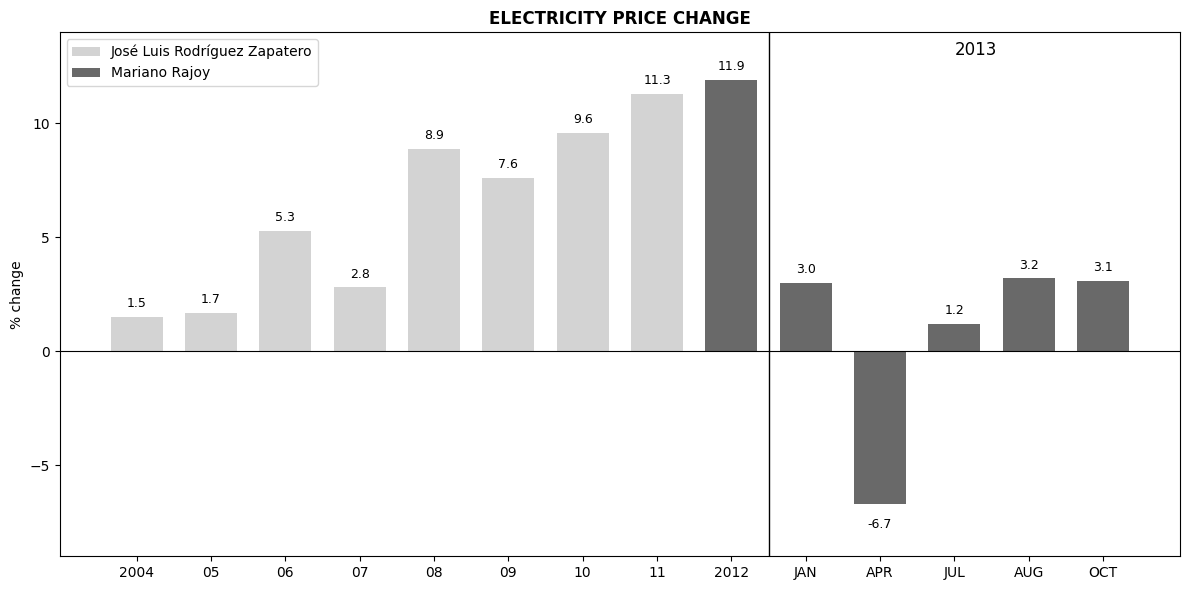

In [4]:
labels = ["2004", "05", "06", "07", "08", "09", "10", "11", "2012",
          "JAN", "APR", "JUL", "AUG", "OCT"]

values = [1.5, 1.7, 5.3, 2.8, 8.9, 7.6, 9.6, 11.3, 11.9,
          3.0, -6.7, 1.2, 3.2, 3.1]

colors = ["lightgrey"] * 8 + ["dimgrey"] * 6

fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(labels, values, color=colors, width=0.7)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (0.3 if val >= 0 else -0.6),
            str(val),
            ha='center', va='bottom' if val >= 0 else 'top',
            fontsize=9)

ax.axvline(x=8.5, color='black', linewidth=1)

ax.text(11, 13, "2013", fontsize=12)
ax.set_title("ELECTRICITY PRICE CHANGE", fontweight='bold')
ax.set_ylabel("% change")
ax.set_ylim(-9, 14)
ax.axhline(0, color='black', linewidth=0.8)

legend_elements = [Patch(facecolor='lightgrey', label='José Luis Rodríguez Zapatero'),
                   Patch(facecolor='dimgrey',   label='Mariano Rajoy')]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()
          

# Improved Chart

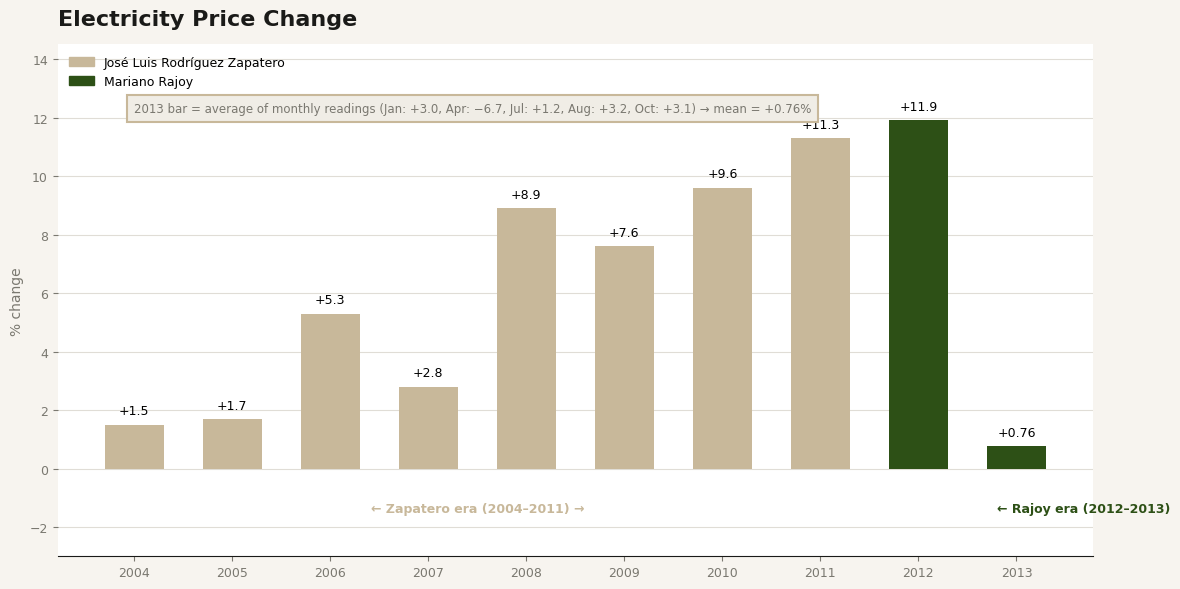

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

labels = ["2004", "2005", "2006", "2007", "2008", "2009", "2010", "2011", "2012", "2013"]
values = [1.5, 1.7, 5.3, 2.8, 8.9, 7.6, 9.6, 11.3, 11.9, 0.76]
party  = ["zap"] * 8 + ["raj"] * 2

colors = ["#C8B89A" if p == "zap" else "#2D5016" for p in party]

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#F7F4EF")
ax.set_facecolor("#ffffff")

bars = ax.bar(labels, values, color=colors, width=0.6, zorder=2)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + 0.25,
            f"+{val}" if val > 0 else str(val),
            ha='center', va='bottom', fontsize=9, fontweight='500')

ax.text(3.5, -1.5, "← Zapatero era (2004–2011) →",
        ha='center', fontsize=9, color='#C8B89A', fontweight='bold')
ax.text(8.8, -1.5, "← Rajoy era (2012–2013)",
        ha='left', fontsize=9, color='#2D5016', fontweight='bold')

ax.text(0, 12.2,
        "2013 bar = average of monthly readings (Jan: +3.0, Apr: −6.7, Jul: +1.2, Aug: +3.2, Oct: +3.1) → mean = +0.76%",
        fontsize=8.5, color='#7A7870',
        bbox=dict(facecolor='#F0EDE6', edgecolor='#C8B89A', linewidth=1.5, pad=5))

ax.set_title("Electricity Price Change", fontsize=16, fontweight='bold',
             color='#1A1A18', pad=14, loc='left')
ax.set_ylabel("% change", fontsize=10, color='#7A7870')
ax.set_ylim(-3, 14.5)

ax.yaxis.grid(True, color='#E0DDD6', linewidth=0.8, zorder=0)
ax.set_axisbelow(True)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#1A1A18')
ax.tick_params(colors='#7A7870', labelsize=9)

zap_patch = mpatches.Patch(color='#C8B89A', label='José Luis Rodríguez Zapatero')
raj_patch  = mpatches.Patch(color='#2D5016', label='Mariano Rajoy')
ax.legend(handles=[zap_patch, raj_patch], fontsize=9, frameon=False, loc='upper left')

plt.tight_layout()
plt.show()

# Key changes:
- The year 2013 is represented by one bar calculated from the average of electricity price changes in JAN: 3.0, APR: -6.7, JUL: 1.2, AUG: 3.2, OCT: 3.1.
- Rename the year on the axis to 20XX format to remain consistent
- The legend is simplified. There is no more need to distinguish "monthly positive" vs "monthly negative"
- I have added a warning banner which explains that average is used for 2013 transparently

# Reflection
a. Why the original was misleading or ineffective?

The original chart is poorly designed as the x-axis is not consistently labelled. It silently mixed in different time scales without explicitly warning the reader. The left 8 bars displayed annual percentage changes (2004 - 2012) while the right 5 bars abruptly switched to monthly percentage changes in 2013 (January, April, July, August, October). Since all bars are equally spaced on the x-axis, side-by-side, it creates a strong visual impression that each bar represented the same unit of time. This made direct comparison between the other years and year 2013 misleading. 


b. What Principles Guided the Redesign?

**Honesty and transparency**. Following Tufte's concept of the data-ink ratio and his warnings against chartjunk, every design decision was made to serve the data rather than obscure it. The most important intervention was resolving the time-scale inconsistency by averaging the five 2013 monthly readings into a single annual-equivalent bar, making all ten bars directly comparable on a consistent yearly scale.
**Preattentive visual encoding** shaped the colour choices. Rather than using colour solely to distinguish political party, colour was also used to encode meaning. I have chosen warm neutral tones for the Zapatero era and deep green for positive Rajoy-era values. This leverages the Gestalt principle of similarity, allowing readers to group bars intuitively before reading a single label.
**Contextual transparency** guided the addition of the note banner, which explicitly states how the 2013 figure was derived. This follows the principle that a good chart should make its own methodology visible, not hidden.

c. How the Redesign Improves Comprehension?

By collapsing the five inconsistent monthly bars into a single averaged 2013 bar, the redesign gives readers a clean,  timeline from 2004 to 2013. We can explicitly see that electricity prices rose steeply and consistently throughout the Zapatero years, peaked at +11.9% in 2012, and then the rate of increase slowed dramatically to near-flat (+0.76%) in 2013 under Rajoy. This pattern was impossible to read confidently in the original because the visual clutter of five uneven monthly bars obscured the overall 2013 trend. The original chart also displayed a negative change in price in APR 2013 under Rajoy which is in stark contrast to the rest of the positive changes. This could be done deliberately to show that the electricity price changes in the regime of prime minister Mariano Rajoy have reduced. However, the reality isn’t the same. The redesign does the interpretive work honestly, so the reader can focus on understanding the data rather than decoding the chart.